# LeetCode #57: Insert Interval

https://leetcode.com/problems/insert-interval/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Brute Force** | $O(n \log n)$ | $O(n)$ |
| **Linear Scan** | $O(n)$ | $O(1)$ extra |

---

## Understanding the Methods

### Brute Force
Append the new interval to the list and sort the whole array by start time, then run the standard merge-intervals sweep. Simple but wastes $O(n \log n)$ time even though the input is already sorted.

### Optimal: Linear Scan ★
Exploit the sorted order with a single left-to-right pass divided into three phases:

1. **Phase 1 — Before:** Copy every existing interval whose end is strictly less than the new interval's start (no overlap possible).
2. **Phase 2 — Merge:** While the current interval's start is $\leq$ the new interval's end, they overlap — expand the new interval to `[min(starts), max(ends)]`.
3. **Phase 3 — After:** Append the merged interval, then copy all remaining existing intervals unchanged.

**Why this is better than Brute Force:** Both have $O(n)$ output, but sorting adds an unnecessary $O(n \log n)$ factor. The linear scan uses the pre-sorted order for free and touches each interval exactly once.

**Constraints:**
* $0 \leq$ intervals.length $\leq 10^4$
* intervals is sorted by start time; no two intervals overlap.
* newInterval.length $= 2$

## Solutions

### C#

In [ ]:
public class Solution {
    public int[][] Insert(int[][] intervals, int[] newInterval) {
        var result = new List<int[]>();
        int i = 0, n = intervals.Length;

        // Phase 1: copy every interval that ends before the new interval starts
        while (i < n && intervals[i][1] < newInterval[0]) {
            result.Add(intervals[i++]);
        }

        // Phase 2: merge all overlapping intervals into newInterval
        while (i < n && intervals[i][0] <= newInterval[1]) {
            newInterval[0] = Math.Min(newInterval[0], intervals[i][0]);
            newInterval[1] = Math.Max(newInterval[1], intervals[i][1]);
            i++;
        }
        result.Add(newInterval);   // commit the (possibly expanded) merged interval

        // Phase 3: copy all remaining intervals that start after the merged interval
        while (i < n) {
            result.Add(intervals[i++]);
        }

        return result.ToArray();
    }
}

### Python

In [ ]:
class Solution:
    def insert(self, intervals: list[list[int]], new_interval: list[int]) -> list[list[int]]:
        result = []
        i, n = 0, len(intervals)

        # Phase 1: copy every interval that ends before the new interval starts
        while i < n and intervals[i][1] < new_interval[0]:
            result.append(intervals[i])
            i += 1

        # Phase 2: merge all overlapping intervals into new_interval
        while i < n and intervals[i][0] <= new_interval[1]:
            new_interval[0] = min(new_interval[0], intervals[i][0])
            new_interval[1] = max(new_interval[1], intervals[i][1])
            i += 1
        result.append(new_interval)  # commit the (possibly expanded) merged interval

        # Phase 3: copy all remaining intervals that start after the merged interval
        while i < n:
            result.append(intervals[i])
            i += 1

        return result

### Go

In [ ]:
func insert(intervals [][]int, newInterval []int) [][]int {
    result := [][]int{}
    i, n := 0, len(intervals)

    // Phase 1: copy every interval that ends before the new interval starts
    for i < n && intervals[i][1] < newInterval[0] {
        result = append(result, intervals[i])
        i++
    }

    // Phase 2: merge all overlapping intervals into newInterval
    for i < n && intervals[i][0] <= newInterval[1] {
        if intervals[i][0] < newInterval[0] {
            newInterval[0] = intervals[i][0]
        }
        if intervals[i][1] > newInterval[1] {
            newInterval[1] = intervals[i][1]
        }
        i++
    }
    result = append(result, newInterval) // commit the (possibly expanded) merged interval

    // Phase 3: copy all remaining intervals that start after the merged interval
    for i < n {
        result = append(result, intervals[i])
        i++
    }

    return result
}

### Rust

In [ ]:
impl Solution {
    pub fn insert(intervals: Vec<Vec<i32>>, mut new_interval: Vec<i32>) -> Vec<Vec<i32>> {
        let mut result: Vec<Vec<i32>> = Vec::new();
        let n = intervals.len();
        let mut i = 0;

        // Phase 1: copy every interval that ends before the new interval starts
        while i < n && intervals[i][1] < new_interval[0] {
            result.push(intervals[i].clone());
            i += 1;
        }

        // Phase 2: merge all overlapping intervals into new_interval
        while i < n && intervals[i][0] <= new_interval[1] {
            new_interval[0] = new_interval[0].min(intervals[i][0]);
            new_interval[1] = new_interval[1].max(intervals[i][1]);
            i += 1;
        }
        result.push(new_interval); // commit the (possibly expanded) merged interval

        // Phase 3: copy all remaining intervals that start after the merged interval
        while i < n {
            result.push(intervals[i].clone());
            i += 1;
        }

        result
    }
}

## Example Scenarios

### 1. Insert at Start (No Overlap)
**Input:** `intervals = [[3,5],[6,9]]`, `newInterval = [1,2]`  
The new interval ends at 2, which is less than 3 (the start of the first existing interval), so Phase 1 never copies anything and Phase 2 finds no overlaps. The merged interval [1,2] is prepended and both originals follow unchanged.

### 2. Insert at End (No Overlap)
**Input:** `intervals = [[1,3],[6,9]]`, `newInterval = [10,12]`  
Both existing intervals end before 10, so Phase 1 copies them both. Phase 2 finds nothing to merge, and Phase 3 appends [10,12] — $O(n)$ with zero expansions.

### 3. Edge Case: Merge with One Interval
**Input:** `intervals = [[1,3],[6,9]]`, `newInterval = [2,5]`  
Phase 1 copies nothing (2 $\leq$ 3). Phase 2 sees that [1,3] overlaps ($1 \leq 5$), expanding the merged interval to [1,5]. [6,9] starts after 5, so Phase 3 appends it. Demonstrates how one overlap triggers a single expansion.

### 4. Edge Case: Merge Multiple (Time Factor)
**Input:** `intervals = [[1,2],[3,5],[6,7],[8,10],[12,16]]`, `newInterval = [4,8]`  
Phase 1 copies [1,2] (ends at 2 $< 4$). Phase 2 absorbs three intervals — [3,5], [6,7], [8,10] — expanding the merged end from 5 $\to$ 7 $\to$ 10, yielding [3,10]. Phase 3 appends [12,16]. This is the worst case for merge work: $O(n)$ iterations with $n-2$ expansions.

### 5. Almost-Impossible but Plausible: Full Overlap (Space Factor)
**Input:** `intervals = [[1,5],[10,15],[20,25]]`, `newInterval = [0,30]`  
The new interval spans every existing one. Phase 1 copies nothing (0 is not $>$ any end). Phase 2 absorbs all three, leaving a single [0,30]. Phase 3 appends nothing. Output is $O(1)$ intervals despite $O(n)$ input — the extreme space-reduction case.

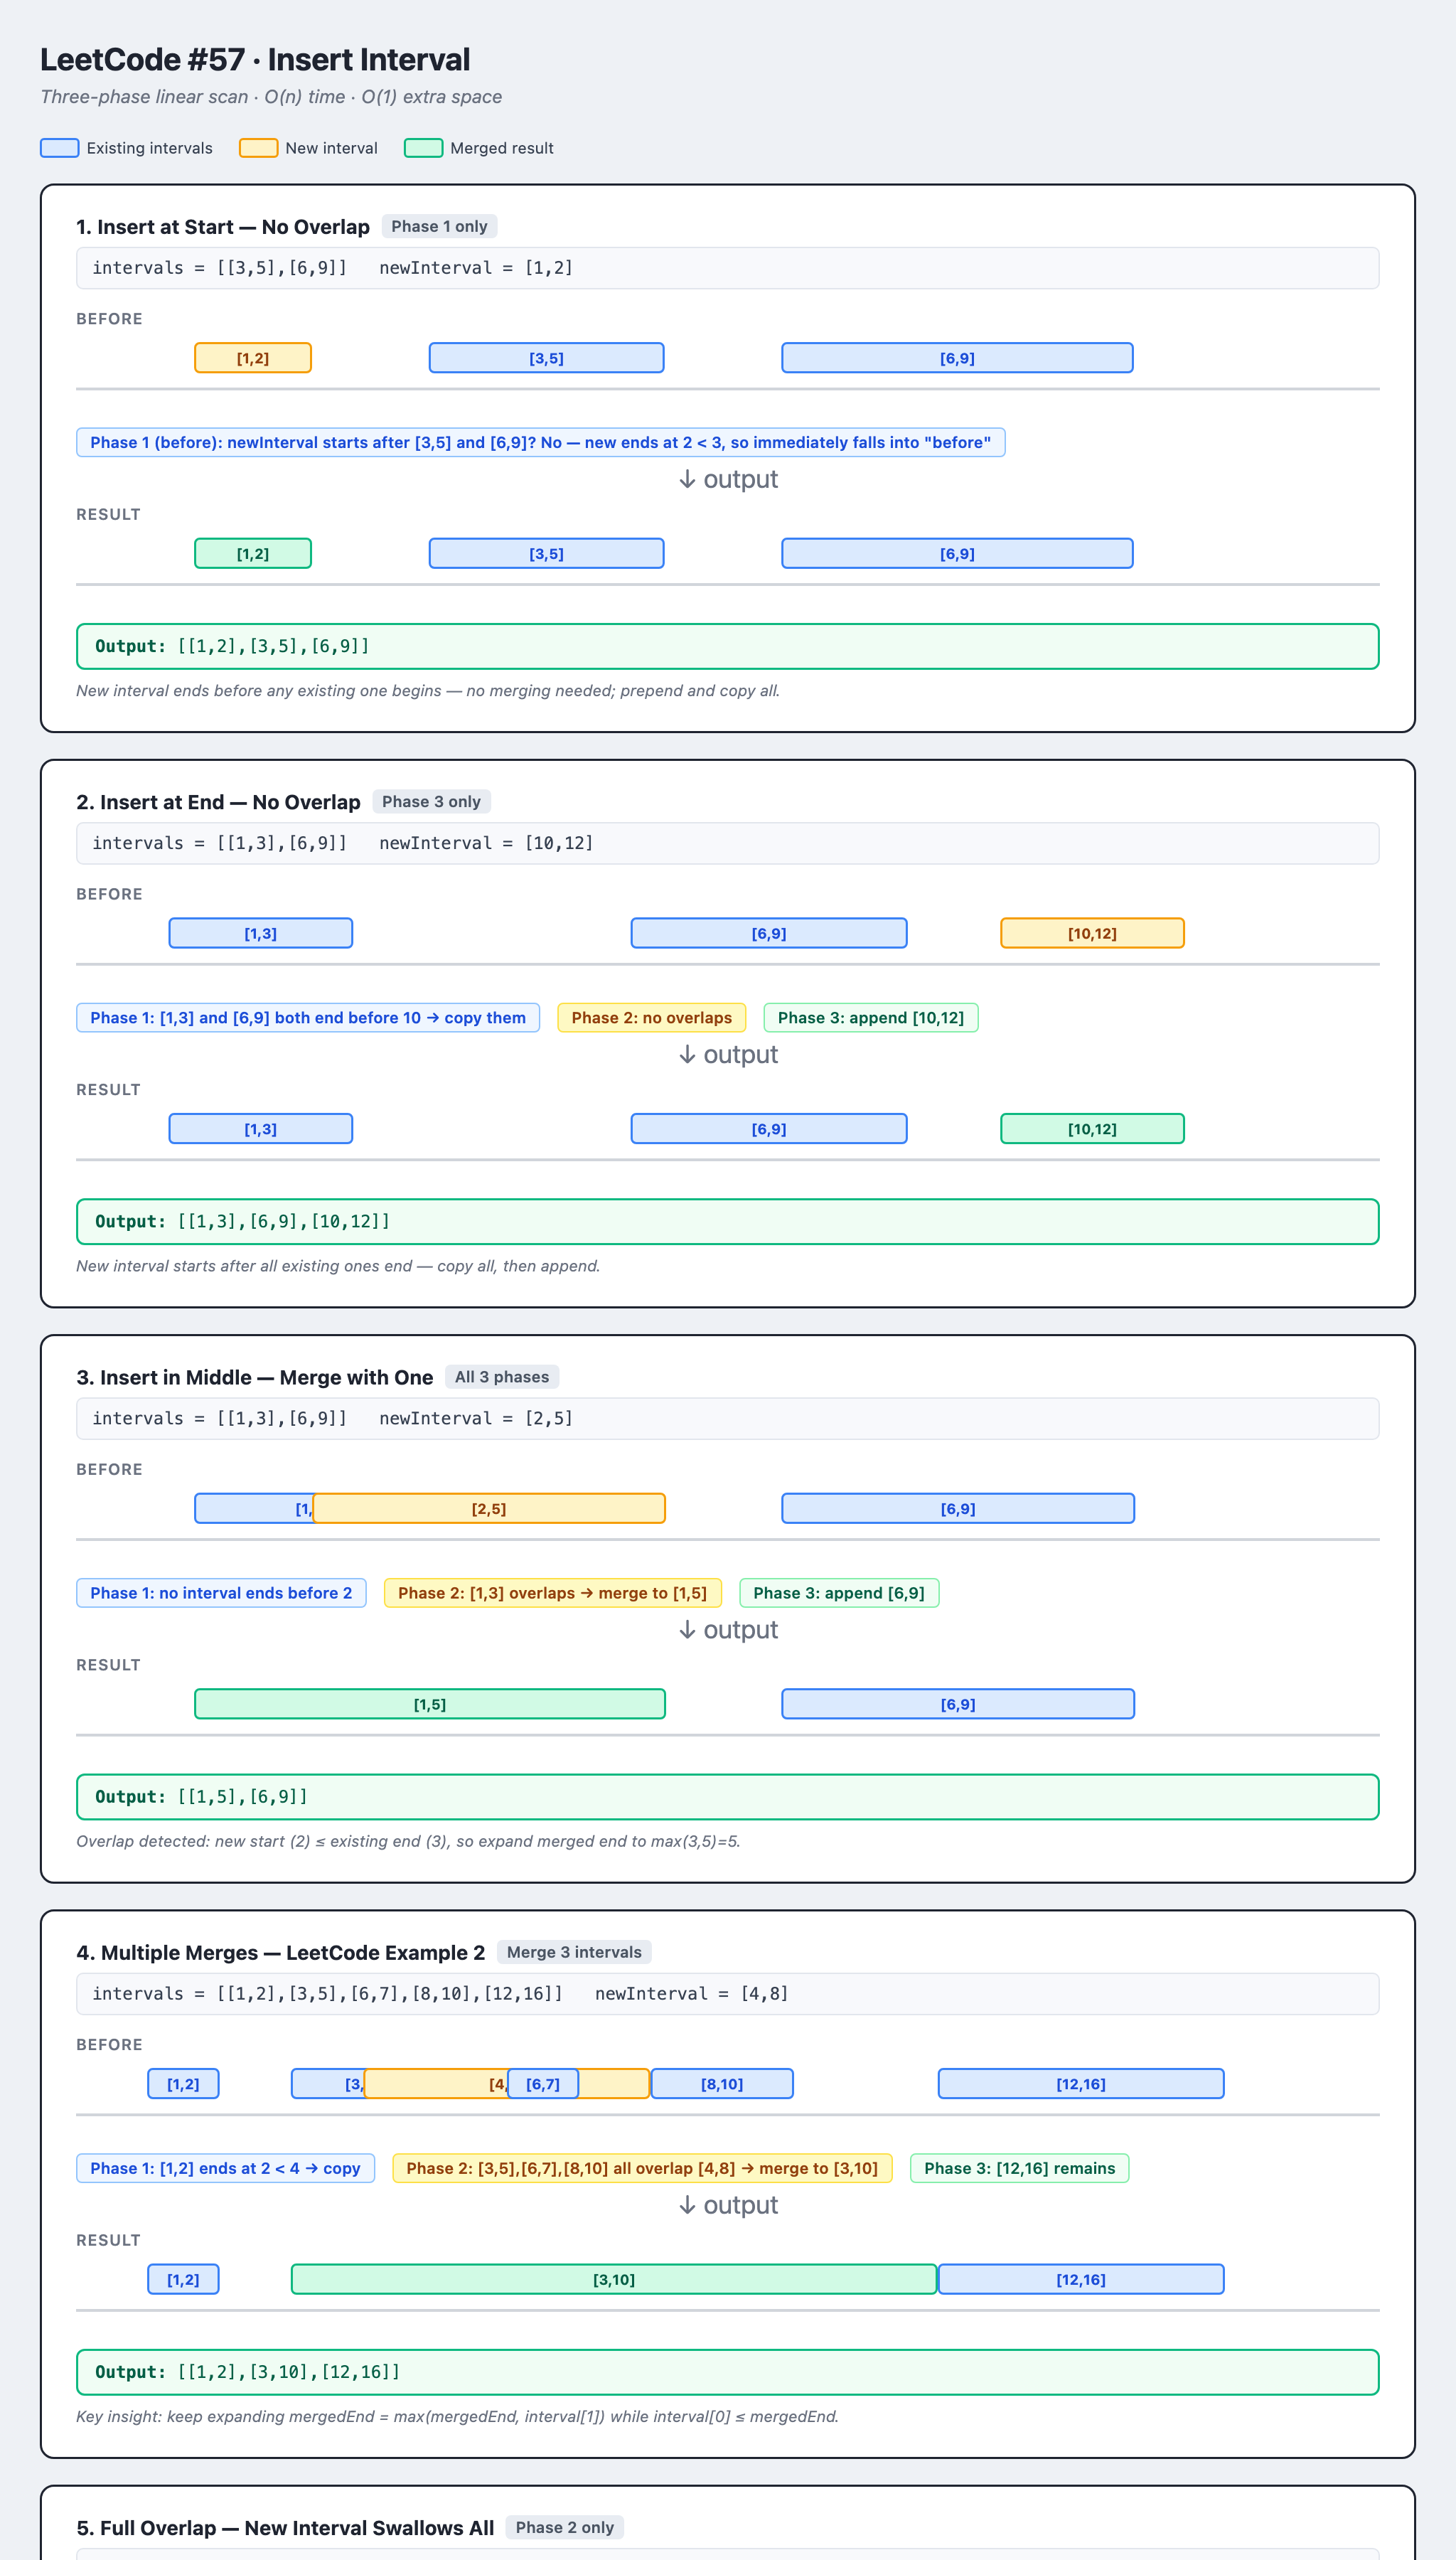